# 01 — Functions on a sphere

Before we can *compress* spherical lighting we need to be fluent in it: how to
parameterise directions, what "integrate over all directions" really means, and
how to compute such an integral without fooling ourselves.

This notebook builds the ground truth that every later notebook is measured
against. Get this wrong and every accuracy claim downstream is worthless.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))

import numpy as np
import matplotlib.pyplot as plt

import shlib as sh
import shplot as sp

sp.use_style()
np.set_printoptions(precision=4, suppress=True, linewidth=110)

## 1. Directions, and the coordinate trap

A direction is a unit vector. We parameterise it with two angles:

$$\begin{aligned}
x &= \sin\theta\,\cos\phi \\
y &= \sin\theta\,\sin\phi \\
z &= \cos\theta
\end{aligned}
\qquad
\begin{aligned}
\theta &\in [0, \pi] \quad\text{polar, measured down from } +Z \\
\phi &\in [0, 2\pi) \quad\text{azimuth, in the XY plane from } +X
\end{aligned}$$

$\theta = 0$ is straight up, $\theta = \pi/2$ is the horizon, $\theta = \pi$ is
straight down.

> **This is the single most common source of bugs in SH code.** Physics papers use
> $\theta$ = polar. Some graphics code uses $\theta$ = azimuth. SciPy's old
> `sph_harm` swapped them relative to its own docs for years. Y-up engines relabel
> the axes entirely. Always pin down the convention before trusting a formula.

In [2]:
# A few landmark directions, to fix the convention in your head.
landmarks = [("+Z  (up)",       0.0,          0.0),
             ("+X  (forward)",  np.pi/2,      0.0),
             ("+Y  (right)",    np.pi/2,      np.pi/2),
             ("horizon at 225", np.pi/2,      5*np.pi/4),
             ("-Z  (down)",     np.pi,        0.0)]

print(f"{'name':<18}{'theta':>8}{'phi':>8}   ->   unit vector")
print("-" * 62)
for name, t, p in landmarks:
    d = sh.dir_from_spherical(t, p)
    print(f"{name:<18}{np.degrees(t):>7.0f}°{np.degrees(p):>7.0f}°   ->   "
          f"[{d[0]:+.3f} {d[1]:+.3f} {d[2]:+.3f}]")

# And the round trip is exact.
rng = np.random.default_rng(7)
d = sh.uniform_sphere_dirs(1000, rng)
t, p = sh.spherical_from_dir(d)
print(f"\nround-trip max error: {np.abs(sh.dir_from_spherical(t, p) - d).max():.2e}")

name                 theta     phi   ->   unit vector
--------------------------------------------------------------
+Z  (up)                0°      0°   ->   [+0.000 +0.000 +1.000]
+X  (forward)          90°      0°   ->   [+1.000 +0.000 +0.000]
+Y  (right)            90°     90°   ->   [+0.000 +1.000 +0.000]
horizon at 225         90°    225°   ->   [-0.707 -0.707 +0.000]
-Z  (down)            180°      0°   ->   [+0.000 +0.000 -1.000]

round-trip max error: 7.77e-16


## 2. Solid angle — why there's a $\sin\theta$

Integrating over the sphere means integrating over **solid angle** $d\omega$, not
over $d\theta\,d\phi$. The two differ by a factor that is easy to forget:

$$d\omega \;=\; \sin\theta \; d\theta \; d\phi$$

The reason is geometric. A patch of $\Delta\theta \times \Delta\phi$ near the pole
covers far less of the sphere than the same patch at the equator, because the
circles of constant $\theta$ shrink to nothing as $\theta \to 0$. The circle at
polar angle $\theta$ has radius $\sin\theta$, so the patch area scales with it.

Total solid angle of the sphere:

$$\int_0^{2\pi}\!\!\int_0^{\pi} \sin\theta \; d\theta \; d\phi = 2\pi \cdot 2 = 4\pi$$

Forgetting the $\sin\theta$ is *the* classic bug: it over-weights the poles, which
in a lighting context means your sky is too bright straight up.

In [3]:
# Numerically confirm 4*pi, and show what forgetting sin(theta) costs you.
n = 2000
th = (np.arange(n) + 0.5) / n * np.pi
ph = (np.arange(2*n) + 0.5) / (2*n) * 2*np.pi
dth, dph = np.pi/n, 2*np.pi/(2*n)

correct = np.sum(np.sin(th)) * dth * np.sum(np.ones(2*n)) * dph
naive   = np.sum(np.ones(n)) * dth * np.sum(np.ones(2*n)) * dph

print(f"with sin(theta):   {correct:.6f}   (4*pi = {4*np.pi:.6f})")
print(f"without:           {naive:.6f}   (this is 2*pi^2 -- wrong by {naive/correct:.1%})")

with sin(theta):   12.566372   (4*pi = 12.566371)
without:           19.739209   (this is 2*pi^2 -- wrong by 157.1%)


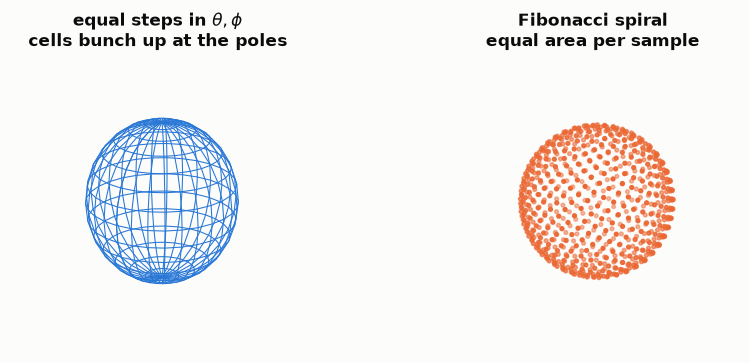

In [4]:
# The same point, visually: equal steps in (theta, phi) are NOT equal areas.
fig = plt.figure(figsize=(8.4, 3.4))

ax = fig.add_subplot(121, projection="3d")
T, P = np.meshgrid(np.linspace(0.001, np.pi-0.001, 15), np.linspace(0, 2*np.pi, 30),
                   indexing="ij")
D = sh.dir_from_spherical(T, P)
ax.plot_wireframe(D[...,0], D[...,1], D[...,2], color=sp.SERIES[0], lw=0.7)
ax.set_title("equal steps in $\\theta,\\phi$\ncells bunch up at the poles")
ax.set_axis_off(); ax.set_box_aspect((1,1,1)); ax.view_init(elev=22, azim=35)

ax = fig.add_subplot(122, projection="3d")
d = sh.fibonacci_sphere(700)
ax.scatter(d[:,0], d[:,1], d[:,2], s=6, color=sp.SERIES[1])
ax.set_title("Fibonacci spiral\nequal area per sample")
ax.set_axis_off(); ax.set_box_aspect((1,1,1)); ax.view_init(elev=22, azim=35)
fig.tight_layout()

## 3. Integrating by sampling

We will need integrals of the form $\int_\Omega f(\boldsymbol\omega)\,d\omega$
constantly. Two practical ways:

**Monte Carlo with uniform samples.** Draw $N$ directions uniformly over the
sphere. Each carries $4\pi/N$ of solid angle:

$$\int_\Omega f \; d\omega \;\approx\; \frac{4\pi}{N}\sum_{k=1}^{N} f(\boldsymbol\omega_k)$$

To draw uniformly, sample $z$ **uniformly in $[-1,1]$** and $\phi$ uniformly in
$[0,2\pi)$. Not $\theta$ uniformly — that clusters at the poles. (This is
Archimedes' hat-box theorem: the sphere's area is uniform in $z$.)

**Quasi-Monte Carlo with a Fibonacci spiral.** Same estimator, but deterministic,
near-uniform points. Error falls off much faster than random sampling's
$O(N^{-1/2})$. For *projecting* an environment once, offline, this is what you
want — no noise, reproducible.

at N=65536:  random 3.85e-03   fibonacci 2.33e-10


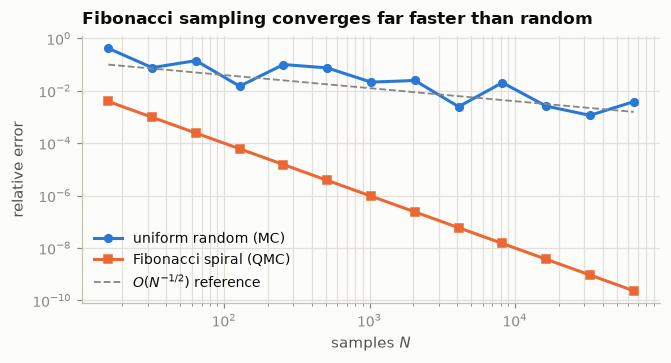

In [5]:
# A test function with a known analytic integral, so we can measure real error.
#   f(d) = (n . d)^2  over the whole sphere  =  4*pi/3
axis = np.array([0.0, 0.0, 1.0])
f = lambda d: (d @ axis) ** 2
exact = 4 * np.pi / 3

counts = np.array([2**k for k in range(4, 17)])
err_mc, err_fib = [], []
rng = np.random.default_rng(0)
for n in counts:
    d = sh.uniform_sphere_dirs(n, rng)
    err_mc.append(abs((4*np.pi/n) * f(d).sum() - exact) / exact)
    d = sh.fibonacci_sphere(n)
    err_fib.append(abs((4*np.pi/n) * f(d).sum() - exact) / exact)

fig, ax = plt.subplots(figsize=(6.2, 3.4))
ax.loglog(counts, err_mc,  "o-", color=sp.SERIES[0], label="uniform random (MC)")
ax.loglog(counts, err_fib, "s-", color=sp.SERIES[1], label="Fibonacci spiral (QMC)")
ax.loglog(counts, 0.4/np.sqrt(counts), "--", color=sp.MUTED, lw=1.2,
          label="$O(N^{-1/2})$ reference")
ax.set_xlabel("samples $N$"); ax.set_ylabel("relative error")
ax.set_title("Fibonacci sampling converges far faster than random")
ax.legend(); ax.grid(True, which="both", axis="both")
fig.tight_layout()

print(f"at N={counts[-1]}:  random {err_mc[-1]:.2e}   fibonacci {err_fib[-1]:.2e}")

The Fibonacci spiral is orders of magnitude more accurate for the same budget —
that is why `shlib.project_env` uses it by default.

(Its curve gets ragged at the right-hand end because the error has dropped near
the level where the sum's own floating-point rounding dominates. That is a good
problem to have.)

## 4. Irradiance, computed honestly

Now the integral we actually care about:

$$E(\mathbf{n}) \;=\; \int_{\Omega} L(\boldsymbol\omega)\,\max(0,\ \mathbf{n}\cdot\boldsymbol\omega)\;d\omega$$

Two ways to estimate it:

1. **Uniform sampling with an explicit cosine factor** — sample the whole sphere,
   multiply each sample by $\max(0, \mathbf{n}\cdot\boldsymbol\omega)$. Simple, but
   wasteful: half the samples land in the hemisphere below the surface and are
   multiplied by zero.

2. **Cosine-weighted sampling** — draw directions with probability density
   $p(\boldsymbol\omega) = \cos\theta/\pi$ over the hemisphere. The cosine in the
   integrand cancels against the cosine in the density, and the estimator collapses
   to something beautiful:

   $$E(\mathbf{n}) \;\approx\; \frac{\pi}{N}\sum_k L(\boldsymbol\omega_k)$$

   Just $\pi$ times the **average radiance** over cosine-distributed samples. This
   is what `shscene.shade_ground_truth` uses.

Let's verify they agree.

In [6]:
import shscene as ss

env = ss.sky_studio
n_hat = np.array([0.3, -0.4, 0.87]); n_hat /= np.linalg.norm(n_hat)

# Method 1: uniform sphere + explicit cosine
d = sh.fibonacci_sphere(400_000)
e_uniform = (4*np.pi/len(d)) * np.sum(env(d) * np.maximum(0, d @ n_hat)[:, None], axis=0)

# Method 2: cosine-weighted hemisphere, pi * mean
dc = sh.cosine_hemisphere_dirs(400_000, n_hat, np.random.default_rng(3))
e_cosine = np.pi * env(dc).mean(axis=0)

print("irradiance at n =", np.round(n_hat, 3))
print(f"  uniform + cos factor : {np.round(e_uniform, 5)}")
print(f"  cosine-weighted      : {np.round(e_cosine, 5)}")
print(f"  relative difference  : {np.abs(e_uniform-e_cosine).max()/e_uniform.max():.2%}")

irradiance at n = [ 0.299 -0.399  0.867]
  uniform + cos factor : [3.0693 2.2386 2.1049]
  cosine-weighted      : [3.0805 2.2453 2.111 ]
  relative difference  : 0.37%


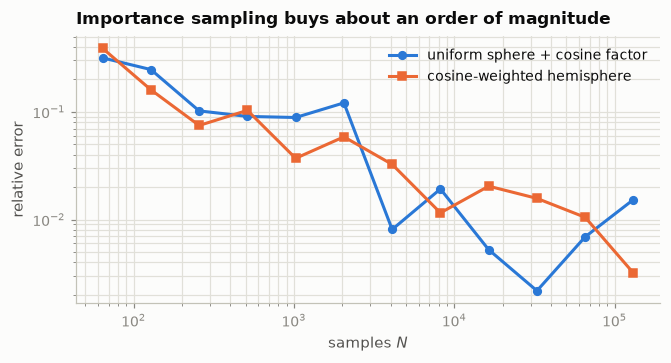

In [7]:
# Convergence: cosine sampling wins because it spends every sample usefully.
ref = e_uniform
counts = np.array([2**k for k in range(6, 18)])
eu, ec = [], []
rng = np.random.default_rng(11)
for n in counts:
    d = sh.uniform_sphere_dirs(n, rng)
    v = (4*np.pi/n) * np.sum(env(d) * np.maximum(0, d @ n_hat)[:, None], axis=0)
    eu.append(np.abs(v - ref).max() / ref.max())
    dc = sh.cosine_hemisphere_dirs(n, n_hat, rng)
    v = np.pi * env(dc).mean(axis=0)
    ec.append(np.abs(v - ref).max() / ref.max())

fig, ax = plt.subplots(figsize=(6.2, 3.4))
ax.loglog(counts, eu, "o-", color=sp.SERIES[0], label="uniform sphere + cosine factor")
ax.loglog(counts, ec, "s-", color=sp.SERIES[1], label="cosine-weighted hemisphere")
ax.set_xlabel("samples $N$"); ax.set_ylabel("relative error")
ax.set_title("Importance sampling buys about an order of magnitude")
ax.legend(); ax.grid(True, which="both", axis="both")
fig.tight_layout()

## 5. What a light probe *is*, stated precisely

Everything above lets us state the problem exactly.

- The environment around a point is a function $L : S^2 \to \mathbb{R}^3$.
- It lives in an **infinite-dimensional** space — there are infinitely many
  distinguishable spherical functions.
- We want to store it in **27 floats** and still get $E(\mathbf{n})$ right.

Compression like this only works if the function has structure we can exploit. The
structure here is *frequency*: real lighting is mostly smooth, and — crucially —
the cosine factor in the irradiance integral smooths it further.

To exploit frequency we need a notion of frequency for functions on a sphere. On
the real line that's the Fourier transform. On a circle it's the Fourier series.
On a sphere it's spherical harmonics, and notebook 02 gets there by starting
somewhere comfortable: the circle.

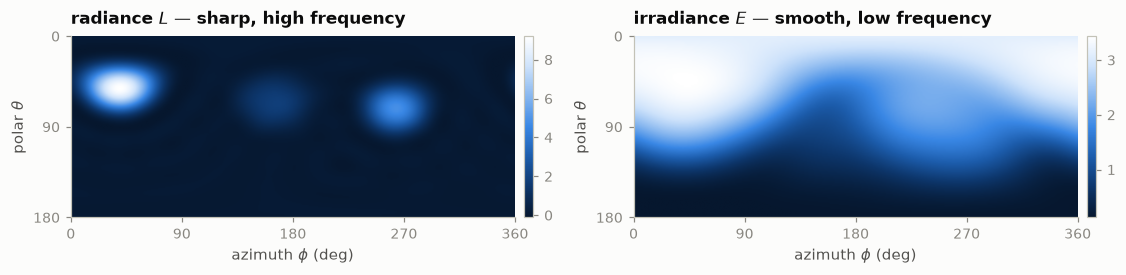

In [8]:
# A preview of the target. Here is one environment, and here is the
# same environment after the cosine convolution that irradiance applies.
c = sh.project_env(env, 12, n_samples=300_000)

radiance  = sh.sh_to_equirect(c, 320, 160)[..., 0]
irradiance = sh.sh_to_equirect(sh.convolve_cosine(c), 320, 160)[..., 0]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 2.6))
sp.show_equirect(radiance, "radiance $L$ — sharp, high frequency", ax=axes[0])
sp.show_equirect(irradiance, "irradiance $E$ — smooth, low frequency", ax=axes[1])
fig.tight_layout()

Look at the right-hand image. **That** is the function a light probe has to
represent — not the left one. It is enormously smoother, and smooth functions need
few coefficients.

That single observation is the entire justification for light probes. Notebook 06
makes it precise.

---

**Next:** [02 — From Fourier series to spherical harmonics](02_fourier_to_sh.ipynb)